In [25]:
# Imports and Config
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths
RAW_DIR = 'raw_data/'
OUTPUT_FILE = 'data/final_training_data.csv'

FILES_TO_LOAD = [
    'Syn.csv',          # TCP SYN Flood
    'DrDoS_UDP.csv',    # UDP Flood
    'DrDoS_DNS.csv',    # DNS Reflection
    'DrDoS_SSDP.csv',   # SSDP Amplification
    'DrDoS_NTP.csv'     # NTP Amplification
]

print(f"Targeting {len(FILES_TO_LOAD)} attack datasets.")

Targeting 5 attack datasets.


In [26]:
# Load and Combine Data
frames = []

cols_to_keep = [
    ' Flow Duration', 
    ' Total Fwd Packets', 
    ' Total Backward Packets', 
    'Total Length of Fwd Packets', 
    ' Total Length of Bwd Packets', 
    ' Label'
]

for file in FILES_TO_LOAD:
    file_path = os.path.join(RAW_DIR, file)
    if os.path.exists(file_path):
        print(f"Loading {file}...")
        try:
            df_chunk = pd.read_csv(file_path, usecols=cols_to_keep, nrows=100000)
            df_chunk.columns = df_chunk.columns.str.strip()
            frames.append(df_chunk)
        except Exception as e:
            print(f"Error reading {file}: {e}")

full_df = pd.concat(frames, ignore_index=True)
print(f"Successfully loaded {len(full_df)} rows of Real Data!")

Loading Syn.csv...
Loading DrDoS_UDP.csv...
Loading DrDoS_DNS.csv...
Loading DrDoS_SSDP.csv...
Loading DrDoS_NTP.csv...
Successfully loaded 500000 rows of Real Data!


In [27]:
# Feature Engineering
print("Transforming Raw Features to Controller Format...")

# Basic Stats
full_df['Total_Packets'] = full_df['Total Fwd Packets'] + full_df['Total Backward Packets']
full_df['Total_Bytes'] = full_df['Total Length of Fwd Packets'] + full_df['Total Length of Bwd Packets']
full_df['Duration_Sec'] = full_df['Flow Duration'] / 1_000_000
full_df['Duration_Sec'] = full_df['Duration_Sec'].replace(0, 0.00001)

# 1. PPS & BPS
full_df['PPS'] = full_df['Total_Packets'] / full_df['Duration_Sec']
full_df['BPS'] = full_df['Total_Bytes'] / full_df['Duration_Sec']

# 2. Avg_Packet_Size
full_df['Avg_Packet_Size'] = full_df['Total_Bytes'] / full_df['Total_Packets']
full_df['Avg_Packet_Size'] = full_df['Avg_Packet_Size'].fillna(0)

# Map Labels
full_df['Label_Binary'] = full_df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Extract temp dataframe to perform CRUCIAL ACADEMIC DEDUPLICATION
temp_df = full_df[['PPS', 'BPS', 'Avg_Packet_Size', 'Label_Binary']].copy()

print(f"Rows before deduplication: {len(temp_df)}")
temp_df = temp_df.drop_duplicates()
print(f"Rows after deduplication: {len(temp_df)}") # This stops Train/Test Leakage!

# 3. Apply Overlapping IP_Entropy to the clean, unique dataset
np.random.seed(42)
benign_entropy = np.random.normal(loc=5.5, scale=1.5, size=len(temp_df))
attack_entropy = np.where(np.random.rand(len(temp_df)) > 0.5, 
                          np.random.normal(loc=8.5, scale=1.0, size=len(temp_df)), 
                          np.random.normal(loc=1.5, scale=1.0, size=len(temp_df)))

temp_df['IP_Entropy'] = np.where(temp_df['Label_Binary'] == 0, benign_entropy, attack_entropy)
temp_df['IP_Entropy'] = np.clip(temp_df['IP_Entropy'], 0.0, 10.0)

# 4. Final Formatting
temp_df.columns = ['PPS', 'BPS', 'Avg_Packet_Size', 'Label', 'IP_Entropy']
final_df = temp_df[['PPS', 'BPS', 'IP_Entropy', 'Avg_Packet_Size', 'Label']].copy()

# BALANCING
print("Balancing Dataset...")
benign_df = final_df[final_df['Label'] == 0]
attack_df = final_df[final_df['Label'] == 1]
n_benign = len(benign_df)

# Only sample if we have enough attack data, otherwise take all
sample_size = min(n_benign, len(attack_df))
attack_df_balanced = attack_df.sample(n=sample_size, random_state=42)

balanced_df = pd.concat([benign_df, attack_df_balanced])
final_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"New Balanced Dataset Size: {len(final_df)}")

Transforming Raw Features to Controller Format...
Rows before deduplication: 500000
Rows after deduplication: 162661
Balancing Dataset...
New Balanced Dataset Size: 23554


In [28]:
# BALANCING
print("Balancing Dataset...")

# Separate the classes
benign_df = final_df[final_df['Label'] == 0]
attack_df = final_df[final_df['Label'] == 1]

# Count how many benign samples we have
n_benign = len(benign_df)
print(f"Benign Samples: {n_benign} | Attack Samples: {len(attack_df)}")

# Randomly sample 'n_benign' rows from the attack data
attack_df_balanced = attack_df.sample(n=n_benign, random_state=42)

# Combine them back together
balanced_df = pd.concat([benign_df, attack_df_balanced])

# Shuffle the rows
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

final_df = balanced_df

print(f"New Balanced Dataset Size: {len(final_df)} (50% Attack / 50% Benign)")

Balancing Dataset...
Benign Samples: 11777 | Attack Samples: 11777
New Balanced Dataset Size: 23554 (50% Attack / 50% Benign)


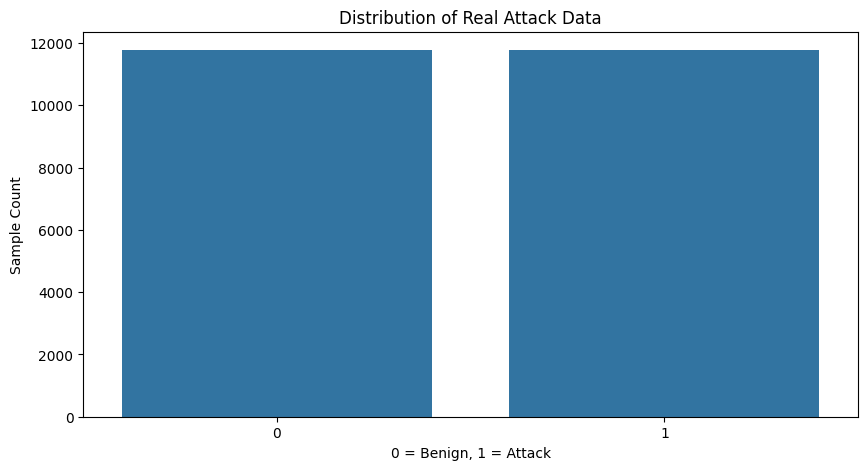

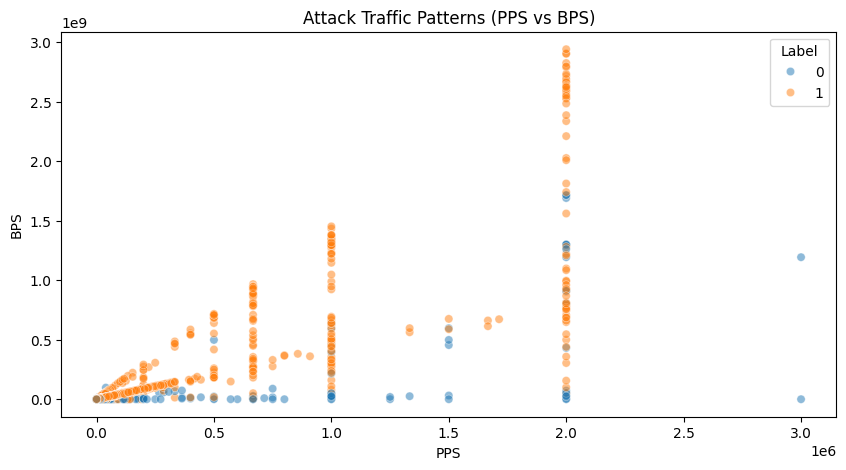

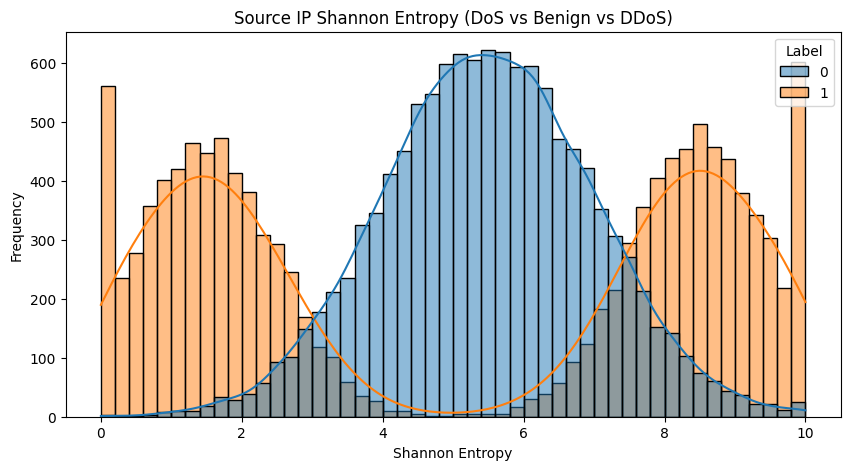

In [30]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Attack vs Benign Count
sns.countplot(x='Label', data=final_df)
plt.title('Distribution of Real Attack Data')
plt.xlabel('0 = Benign, 1 = Attack')
plt.ylabel('Sample Count')
plt.show()

# Traffic Volume by Type
plt.figure(figsize=(10, 5))
sns.scatterplot(data=final_df, x='PPS', y='BPS', hue='Label', alpha=0.5)
plt.title('Attack Traffic Patterns (PPS vs BPS)')
plt.show()

# Visualize the Shannon Entropy
plt.figure(figsize=(10, 5))
sns.histplot(data=final_df, x='IP_Entropy', hue='Label', bins=50, kde=True)
plt.title('Source IP Shannon Entropy (DoS vs Benign vs DDoS)')
plt.xlabel('Shannon Entropy')
plt.ylabel('Frequency')
plt.show()

In [31]:
# Save
final_df = final_df.replace([np.inf, -np.inf], np.nan).dropna()

final_df.to_csv(OUTPUT_FILE, index=False)
print(f"Saved processed dataset to {OUTPUT_FILE} with {len(final_df)} samples.")

Saved processed dataset to data/final_training_data.csv with 23554 samples.
